# CLS-Token Attention Visualization

Inspects what the variable-aware patch borehole transformer encoder attends to when forming the borehole latent embedding.

The CLS token is a learned query that pools information from all `(variable, depth-patch)` tokens into a single latent vector. Its attention weights reveal which geological variables and depth ranges the encoder found most informative.

> **Note:** Attention weight is an interpretability diagnostic, not a perfect causal importance score. High attention to a token means the CLS token drew information from it — but the relationship between attention and downstream prediction is indirect.

In [1]:
import ast
import re
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

os.makedirs("attention_plots", exist_ok=True)

# ── Configuration ─────────────────────────────────────────────────────────────
N_VARIABLES = 5
N_PATCHES   = 22

# Update with your actual geological variable names if known
VARIABLE_NAMES = [f"Var {v}" for v in range(N_VARIABLES)]

CLS_ATTN_PATH = "cls_attn.txt"
LATENT_PATH   = "latent.txt"

## Helper functions

In [2]:
def load_tensor_from_txt(path: str) -> np.ndarray:
    """Load a tensor saved as plain text, NumPy output, or a PyTorch repr string.

    Handles:
      - Plain whitespace-delimited numbers (np.savetxt output)
      - NumPy array repr  (np.array([...]))
      - PyTorch tensor repr  (tensor([...], device='cuda:0'))
    """
    with open(path, "r") as f:
        content = f.read().strip()

    # ── Attempt 1: plain numeric text (np.savetxt / whitespace-delimited) ──────
    try:
        return np.loadtxt(path, dtype=np.float32)
    except Exception:
        pass

    # ── Attempt 2: strip PyTorch / NumPy repr wrappers ───────────────────────
    cleaned = content

    # Remove trailing annotations: device=..., dtype=..., grad_fn=...
    cleaned = re.sub(r",\s*device='[^']*'", "", cleaned)
    cleaned = re.sub(r",\s*device=\"[^\"]*\"", "", cleaned)
    cleaned = re.sub(r",\s*dtype=\w+", "", cleaned)
    cleaned = re.sub(r",\s*grad_fn=<[^>]*>", "", cleaned)

    # Strip outer wrappers: tensor(...) or array(...)
    cleaned = re.sub(r"^tensor\(", "", cleaned)
    cleaned = re.sub(r"^np\.array\(", "", cleaned)
    cleaned = re.sub(r"^array\(", "", cleaned)
    cleaned = cleaned.rstrip(")")

    try:
        data = ast.literal_eval(cleaned)
        return np.array(data, dtype=np.float32)
    except Exception:
        pass

    # ── Attempt 3: brute-force numeric extraction ─────────────────────────────
    numbers = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", content)
    if not numbers:
        raise ValueError(f"Could not parse any numbers from {path}")
    return np.array(numbers, dtype=np.float32)


def reduce_to_variable_patch_attention(
    attn: np.ndarray,
    sample_idx: int = 0,
    n_variables: int = N_VARIABLES,
    n_patches: int = N_PATCHES,
) -> np.ndarray:
    """Reduce an attention tensor of any compatible shape to (n_variables, n_patches).

    Handles the shapes produced by extract_cls_attention():
      (n_layers, B, n_heads, V, P)  — full output, select sample_idx
      (n_layers, n_heads, V, P)     — single sample squeezed
      (n_heads, V, P)               — single layer + sample
      (V, P)                        — already reduced

    Also handles the raw cls row before reshape:
      (..., V*P)                    — last dim is flattened variable-patch tokens

    All dimensions except V and P are averaged over.
    """
    a = attn.copy()

    # If last dim is V*P, reshape to (..., V, P) first
    if a.shape[-1] == n_variables * n_patches and a.ndim >= 1:
        a = a.reshape(*a.shape[:-1], n_variables, n_patches)

    if a.shape[-2:] != (n_variables, n_patches):
        raise ValueError(
            f"Cannot reduce to ({n_variables}, {n_patches}): "
            f"final two dims are {a.shape[-2:]}.  Full shape: {a.shape}"
        )

    # Select sample dimension if present
    # Expected layout after possible reshape: (n_layers, B, n_heads, V, P)
    if a.ndim == 5:          # (n_layers, B, n_heads, V, P)
        a = a[:, sample_idx, :, :, :]  # -> (n_layers, n_heads, V, P)
    elif a.ndim == 4:        # (n_layers OR B, n_heads, V, P)
        pass                 # average over both leading dims below

    # Average over all remaining leading dims (layers, heads)
    while a.ndim > 2:
        a = a.mean(axis=0)

    return a  # (V, P)


def plot_attention_heatmap(
    att_vp: np.ndarray,
    title: str = "CLS-token attention",
    var_names: list = VARIABLE_NAMES,
    ax=None,
) -> plt.Axes:
    """Heatmap of (n_variables, n_patches) CLS attention.

    x-axis: depth patch index  |  y-axis: geological variable
    """
    create_fig = ax is None
    n_vars, n_pat = att_vp.shape
    if create_fig:
        fig, ax = plt.subplots(figsize=(max(7, n_pat * 0.55), max(3, n_vars * 0.6)))

    im = ax.imshow(att_vp, aspect="auto", cmap="viridis",
                   interpolation="nearest")
    ax.set_xticks(range(n_pat))
    ax.set_xticklabels(range(n_pat), fontsize=8)
    ax.set_yticks(range(n_vars))
    ax.set_yticklabels(var_names, fontsize=9)
    ax.set_xlabel("Depth patch index", fontsize=10)
    ax.set_ylabel("Geological variable", fontsize=10)
    ax.set_title(title, fontsize=11, pad=8)

    if create_fig:
        plt.colorbar(im, ax=ax, label="Attention weight")
        plt.tight_layout()

    return ax


def plot_variable_importance(
    att_vp: np.ndarray,
    var_names: list = VARIABLE_NAMES,
    ax=None,
) -> plt.Axes:
    """Bar plot of total CLS attention per geological variable (summed over depth patches).

    A tall bar means the CLS token consistently attended to this variable
    across all depth levels — suggesting it carries globally useful signal.
    """
    create_fig = ax is None
    if create_fig:
        fig, ax = plt.subplots(figsize=(6, 3.5))

    importance = att_vp.sum(axis=1)  # sum over patches
    bars = ax.bar(range(len(var_names)), importance, color="steelblue", edgecolor="white")
    ax.set_xticks(range(len(var_names)))
    ax.set_xticklabels(var_names, fontsize=9)
    ax.set_ylabel("Total attention (summed over depth patches)", fontsize=9)
    ax.set_title("Variable importance", fontsize=11, pad=8)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))

    if create_fig:
        plt.tight_layout()

    return ax


def plot_depth_importance(
    att_vp: np.ndarray,
    ax=None,
) -> plt.Axes:
    """Line plot of total CLS attention per depth patch (summed over geological variables).

    Peaks reveal depth intervals the encoder found most discriminative
    regardless of which variable is examined.
    """
    create_fig = ax is None
    if create_fig:
        fig, ax = plt.subplots(figsize=(8, 3.5))

    depth_importance = att_vp.sum(axis=0)  # sum over variables
    ax.plot(range(len(depth_importance)), depth_importance,
            marker="o", markersize=4, linewidth=1.5, color="steelblue")
    ax.fill_between(range(len(depth_importance)), depth_importance,
                    alpha=0.15, color="steelblue")
    ax.set_xlabel("Depth patch index", fontsize=10)
    ax.set_ylabel("Total attention (summed over variables)", fontsize=9)
    ax.set_title("Depth patch importance", fontsize=11, pad=8)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    if create_fig:
        plt.tight_layout()

    return ax

## Load data

In [3]:
cls_attn_raw = load_tensor_from_txt(CLS_ATTN_PATH)
latent_raw   = load_tensor_from_txt(LATENT_PATH)

print(f"cls_attn shape (raw) : {cls_attn_raw.shape}")
print(f"latent   shape (raw) : {latent_raw.shape}")

cls_attn shape (raw) : (2, 1, 4, 5, 22)
latent   shape (raw) : (1, 128)


## Reshape and interpret dimensions

The expected layout from `extract_cls_attention()` is:
```
(n_layers, B, n_heads, n_variables, n_patches)
```
If the tensor was saved before `extract_cls_attention`, the last dim may be `V*P = 110` (flattened) and will be reshaped automatically.

In [4]:
# Try to infer the shape layout and label the dimensions
s = cls_attn_raw.shape
print(f"Raw shape: {s}")

if len(s) == 5:
    n_layers, n_samples, n_heads, v_dim, p_dim = s
    print(f"  -> n_layers={n_layers}, n_samples={n_samples}, n_heads={n_heads}, "
          f"V={v_dim}, P={p_dim}")
elif len(s) == 4:
    print(f"  -> 4D: could be (n_layers, n_heads, V, P) or (B, n_heads, V, P)")
elif len(s) == 2 and s[-1] == N_VARIABLES * N_PATCHES:
    print(f"  -> 2D flattened ({s[0]} samples, V*P={s[1]}) — will reshape")
elif len(s) == 2 and s == (N_VARIABLES, N_PATCHES):
    print("  -> Already (V, P) — single sample, single layer, heads averaged")
else:
    print(f"  -> Shape not immediately recognised; reduce_to_variable_patch_attention will handle it")

# Determine number of samples for looping
if cls_attn_raw.ndim == 5:
    n_samples_detected = cls_attn_raw.shape[1]
elif cls_attn_raw.ndim == 4:
    n_samples_detected = cls_attn_raw.shape[0]
elif cls_attn_raw.ndim == 2 and cls_attn_raw.shape[-1] == N_VARIABLES * N_PATCHES:
    n_samples_detected = cls_attn_raw.shape[0]
else:
    n_samples_detected = 1

print(f"\nDetected samples: {n_samples_detected}")

Raw shape: (2, 1, 4, 5, 22)
  -> n_layers=2, n_samples=1, n_heads=4, V=5, P=22

Detected samples: 1


## Single-sample attention heatmap

Shows the attention pattern for one borehole.  
Brighter cells indicate `(variable, depth-patch)` tokens that the CLS token drew more information from.

Reduced shape: (5, 22)  (should be (5, 22))


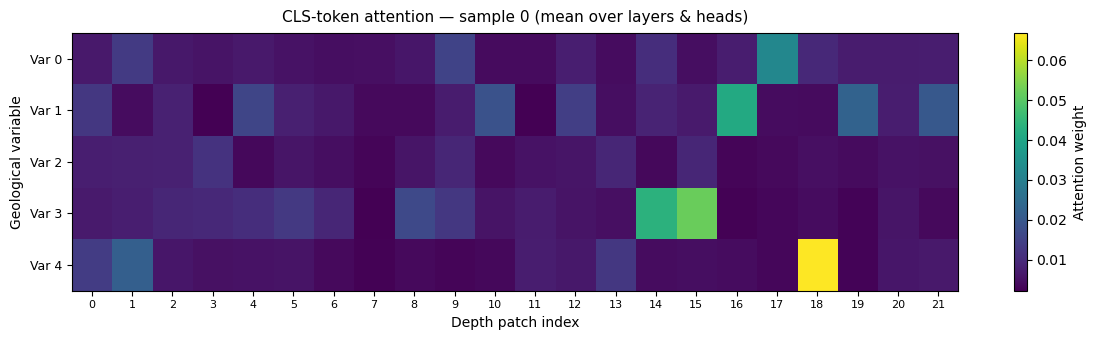

Saved -> attention_plots/sample_attention_heatmap.png


In [5]:
SAMPLE_IDX = 0  # change to inspect a different borehole

att_single = reduce_to_variable_patch_attention(
    cls_attn_raw, sample_idx=SAMPLE_IDX,
    n_variables=N_VARIABLES, n_patches=N_PATCHES,
)

print(f"Reduced shape: {att_single.shape}  (should be ({N_VARIABLES}, {N_PATCHES}))")

fig, ax = plt.subplots(figsize=(12, 3.5))
plot_attention_heatmap(
    att_single,
    title=f"CLS-token attention — sample {SAMPLE_IDX} (mean over layers & heads)",
    var_names=VARIABLE_NAMES,
    ax=ax,
)
plt.colorbar(ax.images[0], ax=ax, label="Attention weight")
plt.tight_layout()
plt.savefig("attention_plots/sample_attention_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> attention_plots/sample_attention_heatmap.png")

## Mean attention heatmap

Averages the attention pattern across all samples in the batch.  
This reveals systematic patterns: which `(variable, depth-patch)` tokens are *consistently* attended to, regardless of the specific borehole.

Mean attention shape: (5, 22)  over 1 sample(s)


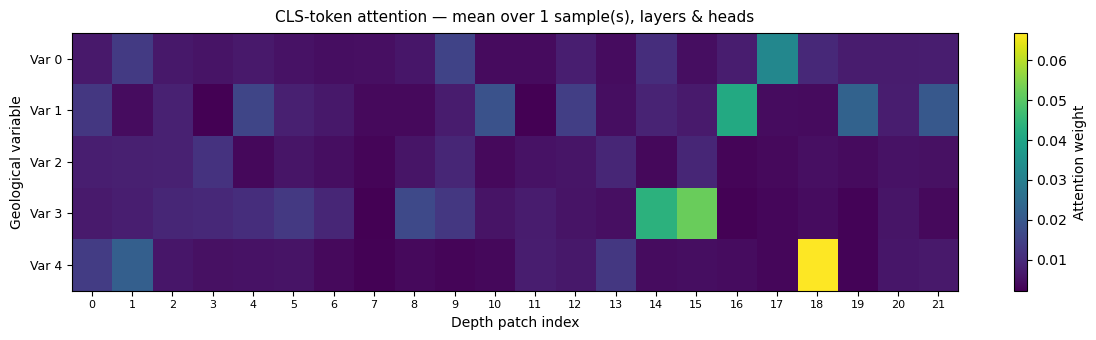

Saved -> attention_plots/mean_attention_heatmap.png


In [6]:
# Collect per-sample attention and average
per_sample = []
for i in range(n_samples_detected):
    try:
        per_sample.append(
            reduce_to_variable_patch_attention(
                cls_attn_raw, sample_idx=i,
                n_variables=N_VARIABLES, n_patches=N_PATCHES,
            )
        )
    except Exception as e:
        print(f"  Skipping sample {i}: {e}")
        break

att_mean = np.stack(per_sample, axis=0).mean(axis=0)  # (V, P)
print(f"Mean attention shape: {att_mean.shape}  over {len(per_sample)} sample(s)")

fig, ax = plt.subplots(figsize=(12, 3.5))
plot_attention_heatmap(
    att_mean,
    title=f"CLS-token attention — mean over {len(per_sample)} sample(s), layers & heads",
    var_names=VARIABLE_NAMES,
    ax=ax,
)
plt.colorbar(ax.images[0], ax=ax, label="Attention weight")
plt.tight_layout()
plt.savefig("attention_plots/mean_attention_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> attention_plots/mean_attention_heatmap.png")

## Variable importance

Sums attention over all depth patches for each geological variable.  
A tall bar means the CLS token consistently draws on that variable across all depths — indicating it carries globally useful signal for the latent embedding.

> Caveat: a variable with low attention here is not necessarily unimportant — it may contribute through residual connections or be attended to unevenly across depths.

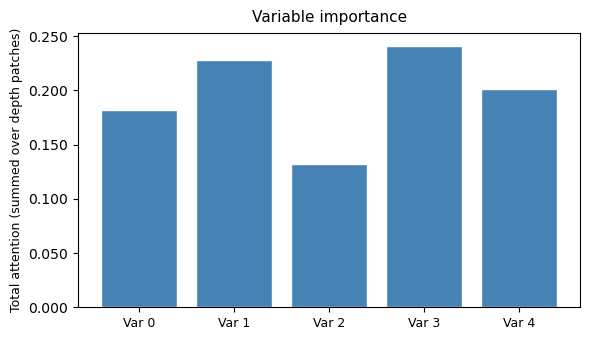

Saved -> attention_plots/variable_importance.png


In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
plot_variable_importance(att_mean, var_names=VARIABLE_NAMES, ax=ax)
plt.tight_layout()
plt.savefig("attention_plots/variable_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> attention_plots/variable_importance.png")

## Depth patch importance

Sums attention over all geological variables for each depth patch.  
Peaks reveal depth intervals that the encoder found most discriminative, regardless of which variable is examined.  
This can be compared to known geological boundaries (e.g., ore horizon depth).

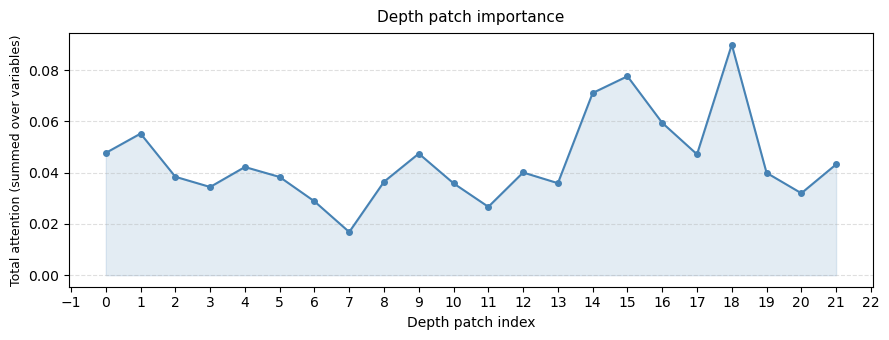

Saved -> attention_plots/depth_importance.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 3.5))
plot_depth_importance(att_mean, ax=ax)
plt.tight_layout()
plt.savefig("attention_plots/depth_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> attention_plots/depth_importance.png")

## Summary

| Plot | File | What it shows |
|---|---|---|
| Single-sample heatmap | `sample_attention_heatmap.png` | Attention map for one borehole (mean over layers/heads) |
| Mean heatmap | `mean_attention_heatmap.png` | Average attention across all samples |
| Variable importance | `variable_importance.png` | Which geological variables are attended to most (summed over depth) |
| Depth importance | `depth_importance.png` | Which depth patches are attended to most (summed over variables) |